In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('credit_card_fraud_10k.csv')

X = df.drop(columns=['transaction_id', 'is_fraud'])
y = df['is_fraud']

numeric_features = ['amount', 'transaction_hour', 'foreign_transaction', 
                    'location_mismatch', 'device_trust_score', 
                    'velocity_last_24h', 'cardholder_age']
categorical_features = ['merchant_category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

In [5]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

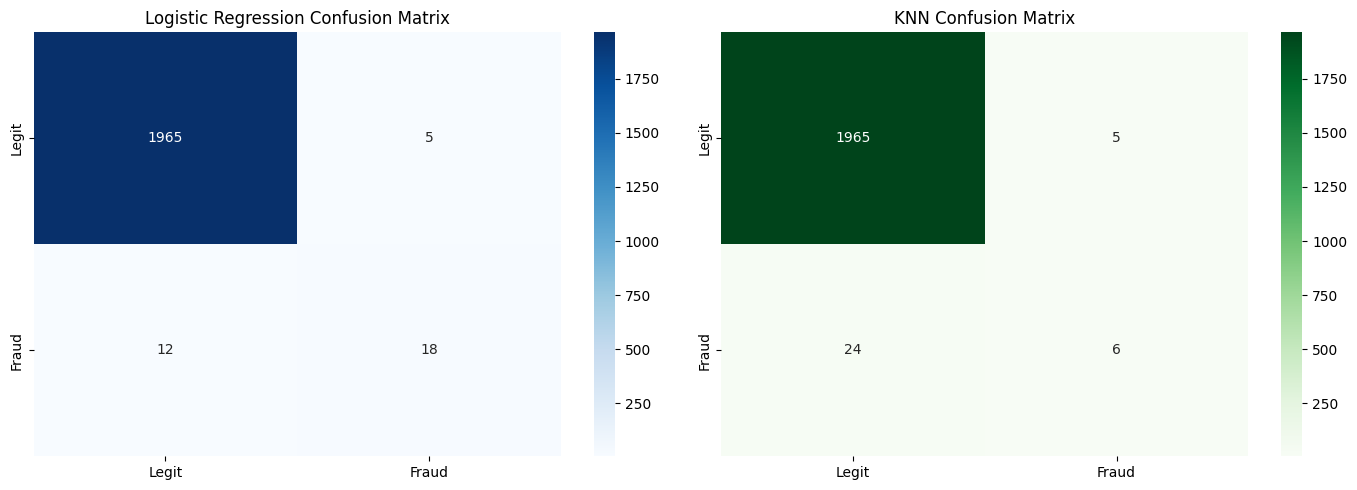

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0].set_title('Logistic Regression Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[1].set_title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

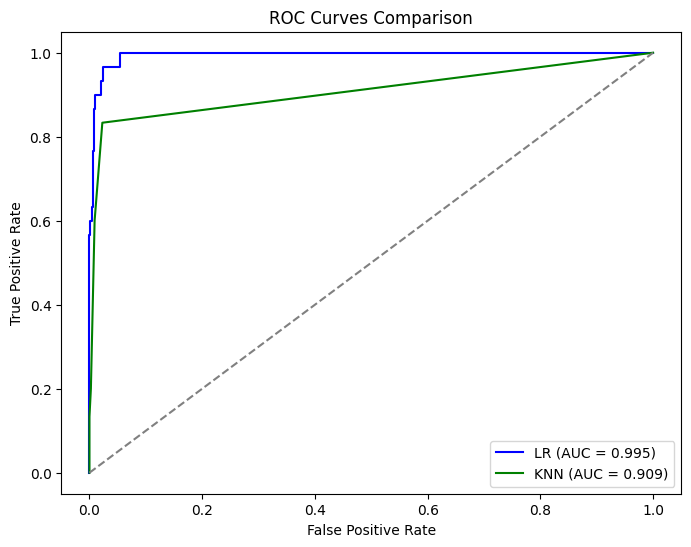

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'LR (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_knn, tpr_knn, color='green', label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

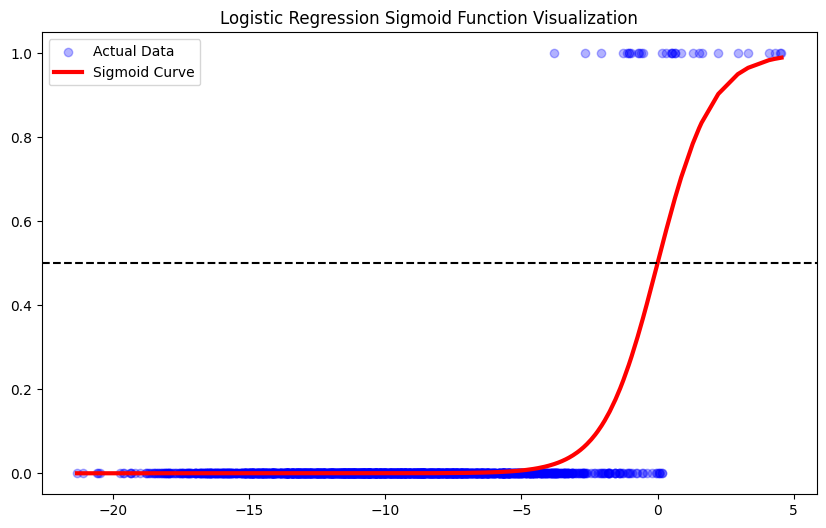

In [8]:
decision_scores = lr_pipeline.decision_function(X_test)
sort_idx = np.argsort(decision_scores)
plt.figure(figsize=(10, 6))
plt.scatter(decision_scores, y_test, color='blue', alpha=0.3, label='Actual Data')
plt.plot(decision_scores[sort_idx], 1 / (1 + np.exp(-decision_scores[sort_idx])), color='red', lw=3, label='Sigmoid Curve')
plt.axhline(0.5, color='black', linestyle='--')
plt.title('Logistic Regression Sigmoid Function Visualization')
plt.legend()
plt.show()

C:\Users\Karunamay\AppData\Local\Temp\ipykernel_6112\606605799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='coolwarm')


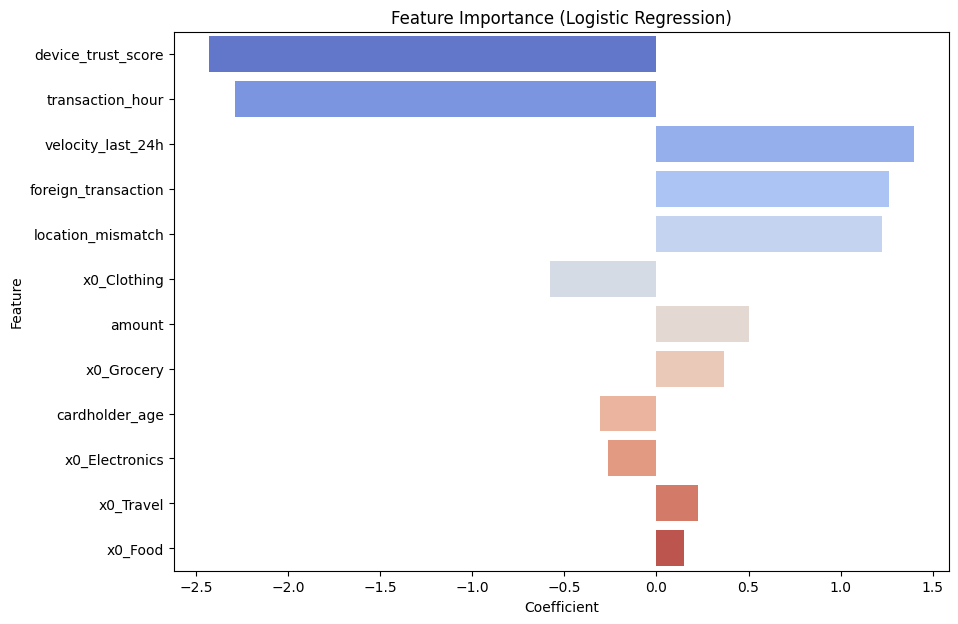

In [9]:
feat_names = numeric_features + list(lr_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out())
importance = pd.DataFrame({'Feature': feat_names, 'Coefficient': lr_pipeline.named_steps['classifier'].coef_[0]})
importance = importance.reindex(importance['Coefficient'].abs().sort_values(ascending=False).index)
plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='coolwarm')
plt.title('Feature Importance (Logistic Regression)')
plt.show()

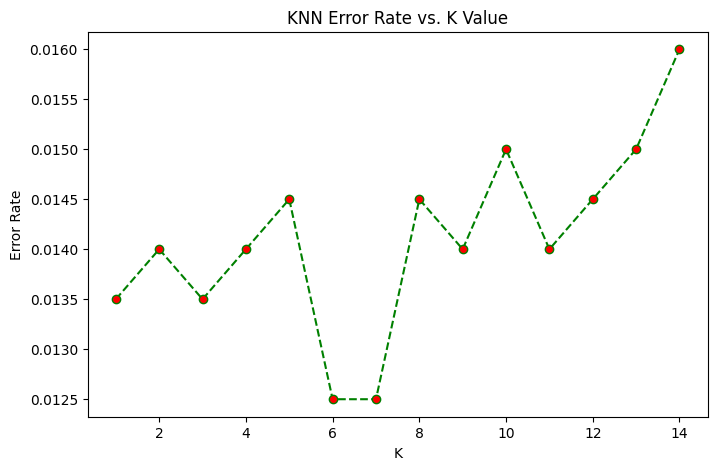

In [10]:
error_rate = []
for i in range(1, 15):
    knn_temp = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=i))])
    knn_temp.fit(X_train, y_train)
    error_rate.append(np.mean(knn_temp.predict(X_test) != y_test))
plt.figure(figsize=(8, 5))
plt.plot(range(1, 15), error_rate, color='green', linestyle='--', marker='o', markerfacecolor='red')
plt.title('KNN Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [11]:
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("KNN Classifier Report:\n", classification_report(y_test, y_pred_knn))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.78      0.60      0.68        30

    accuracy                           0.99      2000
   macro avg       0.89      0.80      0.84      2000
weighted avg       0.99      0.99      0.99      2000

KNN Classifier Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1970
           1       0.55      0.20      0.29        30

    accuracy                           0.99      2000
   macro avg       0.77      0.60      0.64      2000
weighted avg       0.98      0.99      0.98      2000

